# CGRP-Gamma clusters

Used log1p counts

SUbset: pretty neuron fraction
Clustering resolution from previou sscript is 0.25 so pretty coarse.

In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-12-23 12:08:55.435114


In [2]:
from pathlib import Path
import sys
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.patches as mpatches
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import math
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

In [3]:
plt.rcParams['figure.figsize'] = (3,3)
plt.rcParams["figure.dpi"] = 150

In [4]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

input_dir = BASE_DIR / "data/h5ad/export_04/04b_reclustered"
output_dir = BASE_DIR / "data/h5ad/export_04/04c_gamma_subtypes"

output_dir.mkdir(parents=True, exist_ok=True)

input_file = input_dir / "neurons-seurat.h5ad"

In [5]:
sc.settings.figdir = output_dir

In [6]:
def assign_cell_type_colors(adata, key="cell_type"):
    """
    Assigns a tab10 color palette to a categorical obs field.
    If there are more than 10 categories, the palette cycles.
    """
    # Ensure categorical
    adata.obs[key] = adata.obs[key].astype("category")
    
    cats = adata.obs[key].cat.categories
    n = len(cats)

    # tab10 gives 10 colors; using modulo lets us cycle if n > 1=20
    base_palette = sns.color_palette("tab20", 20)

    palette = [mcolors.to_hex(base_palette[i % 20]) for i in range(n)]

    # assign colors in category order
    adata.uns[f"{key}_colors"] = palette

## Prepare data

In [7]:
adata = sc.read_h5ad(input_file)
adata.obs.EGFP_dTomato_dual_hi.value_counts()

EGFP_dTomato_dual_hi
False    22392
True        19
Name: count, dtype: int64

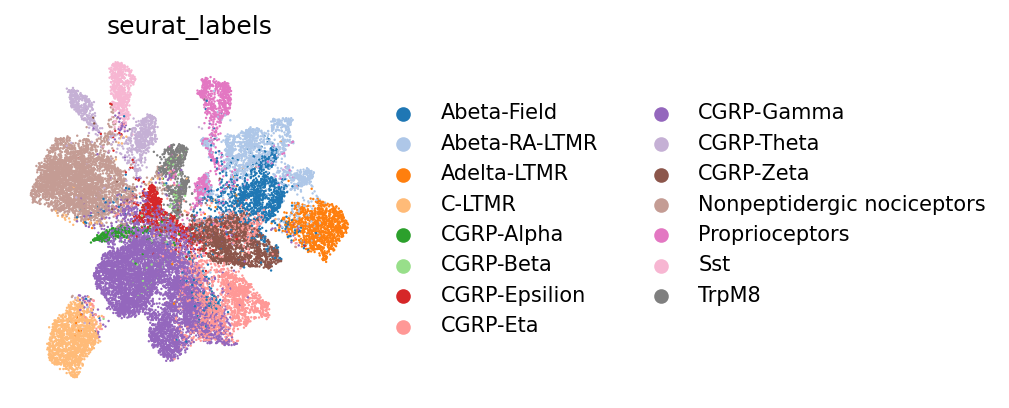

In [8]:
sc.pl.umap(adata, color = 'seurat_labels', frameon = False)

In [9]:
adata.X = adata.layers['log1p'].copy()

### Create `reporter_status` column

In [10]:
# Define conditions with explicit exclusion to ensure dual-positives are prioritized
conditions = [
    adata.obs['EGFP_dTomato_dual_hi'] == True,
    (adata.obs['EGFP_Seq1_hi'] == True) & (adata.obs['EGFP_dTomato_dual_hi'] == False),
    (adata.obs['dTomato_Seq2_hi'] == True) & (adata.obs['EGFP_dTomato_dual_hi'] == False)
]

# Choices remain the same
choices = [
    'EGFP_dTomato_dual_hi', 
    'EGFP_Seq1_hi', 
    'dTomato_Seq2_hi'
]

adata.obs['reporter_status'] = np.select(conditions, choices, default='Negative')

# Convert to categorical for better plotting performance
adata.obs['reporter_status'] = adata.obs['reporter_status'].astype('category')

adata.obs.reporter_status.value_counts()

reporter_status
Negative                22264
dTomato_Seq2_hi            89
EGFP_Seq1_hi               39
EGFP_dTomato_dual_hi       19
Name: count, dtype: int64

### Create `innervation_pattern` column

In [11]:
# Define mapping for broader categories
innervation_map = {
    'EGFP_dTomato_dual_hi': 'Double-positive',
    'EGFP_Seq1_hi': 'Single-positive',
    'dTomato_Seq2_hi': 'Single-positive',
    'Negative': 'Negative'
}

# Apply the map to the existing reporter_status column
adata.obs['innervation_pattern'] = adata.obs['reporter_status'].map(innervation_map)

# Convert to categorical and set a logical order for plotting
adata.obs['innervation_pattern'] = adata.obs['innervation_pattern'].astype('category')
pattern_order = ['Double-positive', 'Single-positive', 'Negative']
adata.obs['innervation_pattern'] = adata.obs['innervation_pattern'].cat.reorder_categories(pattern_order)

print(adata.obs.innervation_pattern.value_counts())

innervation_pattern
Negative           22264
Single-positive      128
Double-positive       19
Name: count, dtype: int64


# Resolve G1/G2

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_7365/866294968.py:7: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(gamma_adata, resolution=0.1, key_added='gamma_subclusters')


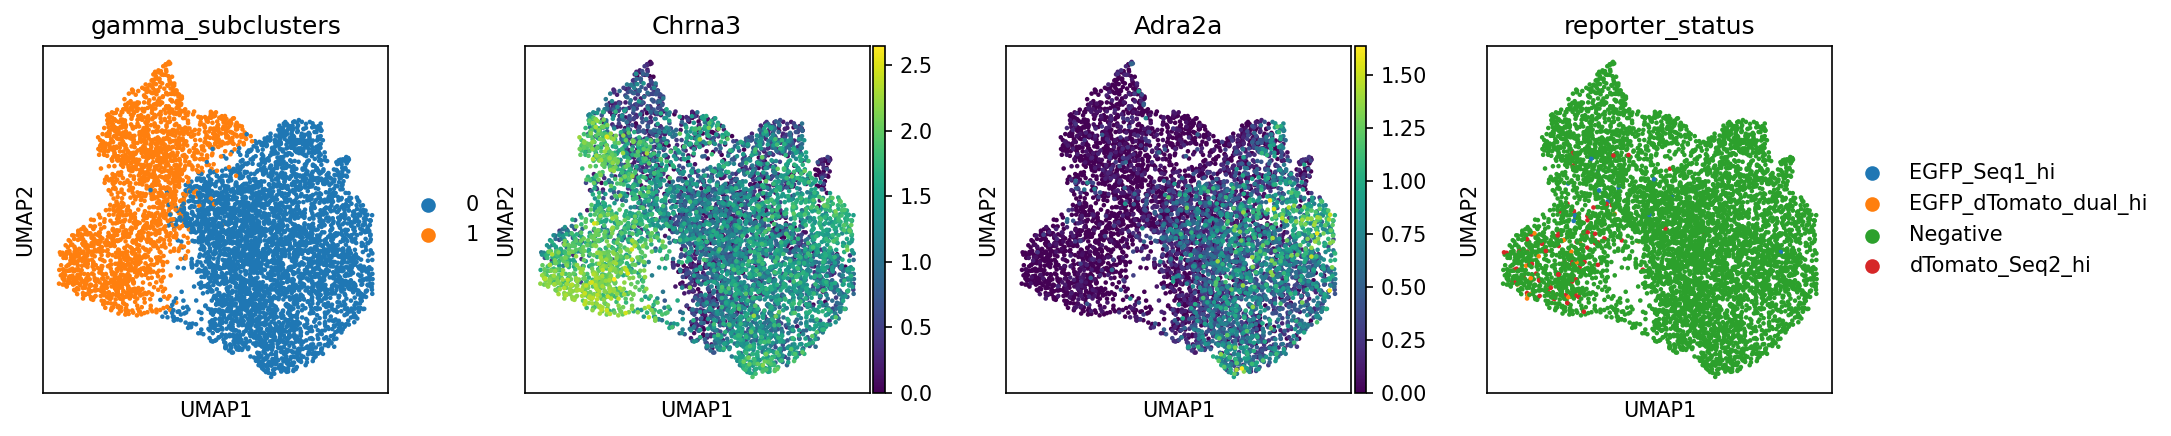

In [12]:
# 1. Subset to the CGRP-Gamma population
gamma_adata = adata[adata.obs['seurat_labels'] == 'CGRP-Gamma'].copy()

# 2. Use scVI latent space instead of PCA for neighbors
sc.pp.neighbors(gamma_adata, use_rep='X_scVI_seurat_neuron')
sc.tl.umap(gamma_adata)
sc.tl.leiden(gamma_adata, resolution=0.1, key_added='gamma_subclusters')

# 3. Identify G1 vs G2 based on Chrna3 mean expression
# Temporarily pull gene expression into .obs to allow grouping
gamma_adata.obs['Chrna3_temp'] = gamma_adata[:, 'Chrna3'].X.toarray().flatten()

cluster_expr = gamma_adata.obs.groupby('gamma_subclusters', observed=False)['Chrna3_temp'].mean()
g2_cluster = cluster_expr.idxmax()
g1_cluster = cluster_expr.idxmin()

# Clean up the temporary column to avoid plotting conflicts
del gamma_adata.obs['Chrna3_temp']

# 4. Create the final labels
label_map = {g1_cluster: 'CGRP-Gamma 1', g2_cluster: 'CGRP-Gamma 2'}
gamma_adata.obs['neuron_labels'] = gamma_adata.obs['gamma_subclusters'].map(label_map)

# Update the main adata object with the new sub-labels
adata.obs['neuron_labels'] = adata.obs['seurat_labels'].astype(str)
adata.obs.update(gamma_adata.obs[['neuron_labels']])
adata.obs['neuron_labels'] = adata.obs['neuron_labels'].astype('category')

# 5. Visualize to confirm the split
sc.pl.umap(gamma_adata, color=['gamma_subclusters', 'Chrna3', 'Adra2a', 'reporter_status'])

In [13]:
import matplotlib.pyplot as plt

def plot_umaps(
    adata,
    label_cols,
    true_color_map,
    false_color,
    true_size,
    false_size,
    edgecolor,
    linewidth,
    alpha_false,
    alpha_true,
    figsize=(3, 3),
):
    """
    Plot minimalist UMAPs for boolean label columns.
    No title, no axes, no border.
    """

    if "X_umap" not in adata.obsm:
        raise ValueError("No UMAP found in adata.obsm['X_umap'].")

    x, y = adata.obsm["X_umap"][:, 0], adata.obsm["X_umap"][:, 1]

    for col in label_cols:
        if col not in adata.obs.columns:
            print(f"Column `{col}` not in adata.obs — skipping.")
            continue

        if col not in true_color_map:
            raise ValueError(f"Missing true_color_map entry for `{col}`.")

        true_color = true_color_map[col]
        mask = adata.obs[col].astype(bool).values

        plt.figure(figsize=figsize)

        # Plot FALSE background
        plt.scatter(
            x[~mask],
            y[~mask],
            s=false_size,
            c=false_color,
            linewidths=0,
            alpha=alpha_false,
        )

        # Plot TRUE foreground
        plt.scatter(
            x[mask],
            y[mask],
            s=true_size,
            c=true_color,
            linewidths=linewidth,
            edgecolors=edgecolor,
            alpha=alpha_true,
        )

        ax = plt.gca()
        ax.set_aspect("equal", "box")

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title("")           # remove title
        ax.spines["top"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["right"].set_visible(False)

        plt.tight_layout()
        plt.show()

In [14]:
labels = ["EGFP_Seq1_hi", "dTomato_Seq2_hi", "EGFP_dTomato_dual_hi"]

true_color_map = {
    "EGFP_Seq1_hi": "limegreen",
    "dTomato_Seq2_hi": "magenta",
    "EGFP_dTomato_dual_hi": "blue",
}

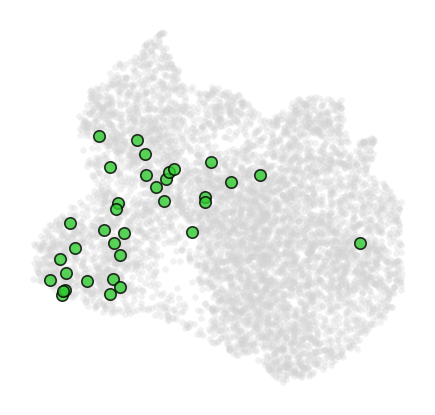

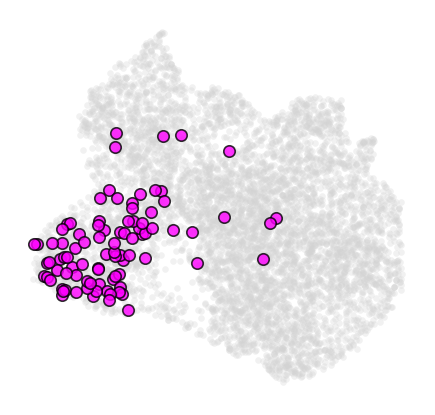

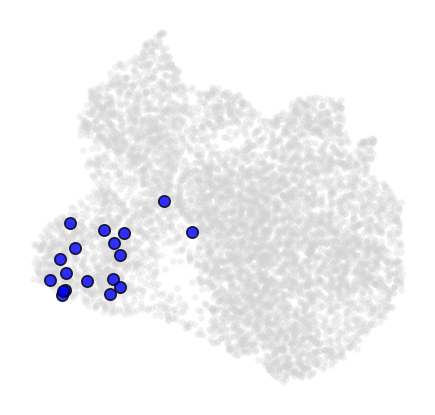

In [15]:
plot_umaps(
    gamma_adata,
    label_cols=labels,
    true_color_map=true_color_map,
    false_color="lightgray",
    true_size=30,
    false_size=10,
    edgecolor="black",
    linewidth=0.8,
    alpha_false=0.3,
    alpha_true=0.8,
)

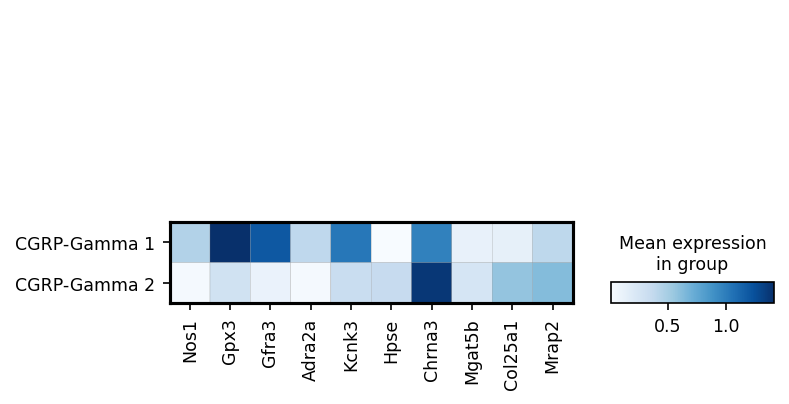

In [44]:
sc.pl.matrixplot(gamma_adata, ['Nos1', 'Gpx3', 'Gfra3', 'Adra2a', 'Kcnk3', 
                                   'Hpse', 'Chrna3', 'Mgat5b', 'Col25a1', 'Mrap2'], groupby='neuron_labels', cmap = 'Blues')

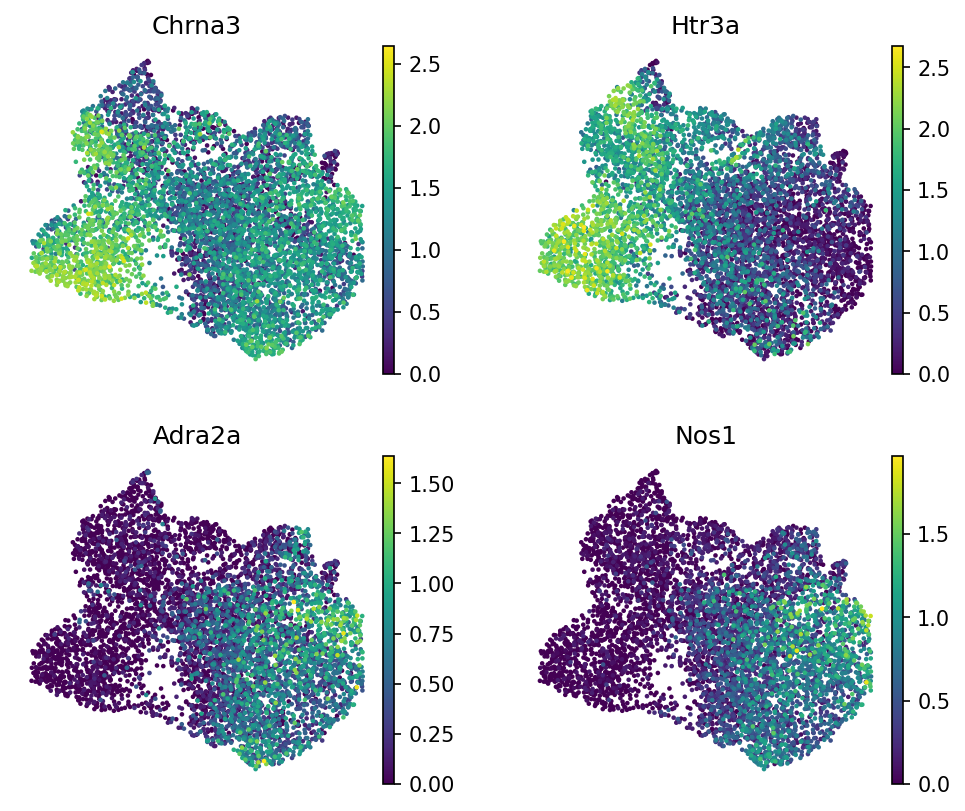

In [36]:
sc.pl.umap(gamma_adata, color=['Chrna3', 'Htr3a', 'Adra2a', 'Nos1'], frameon = False, ncols = 2)

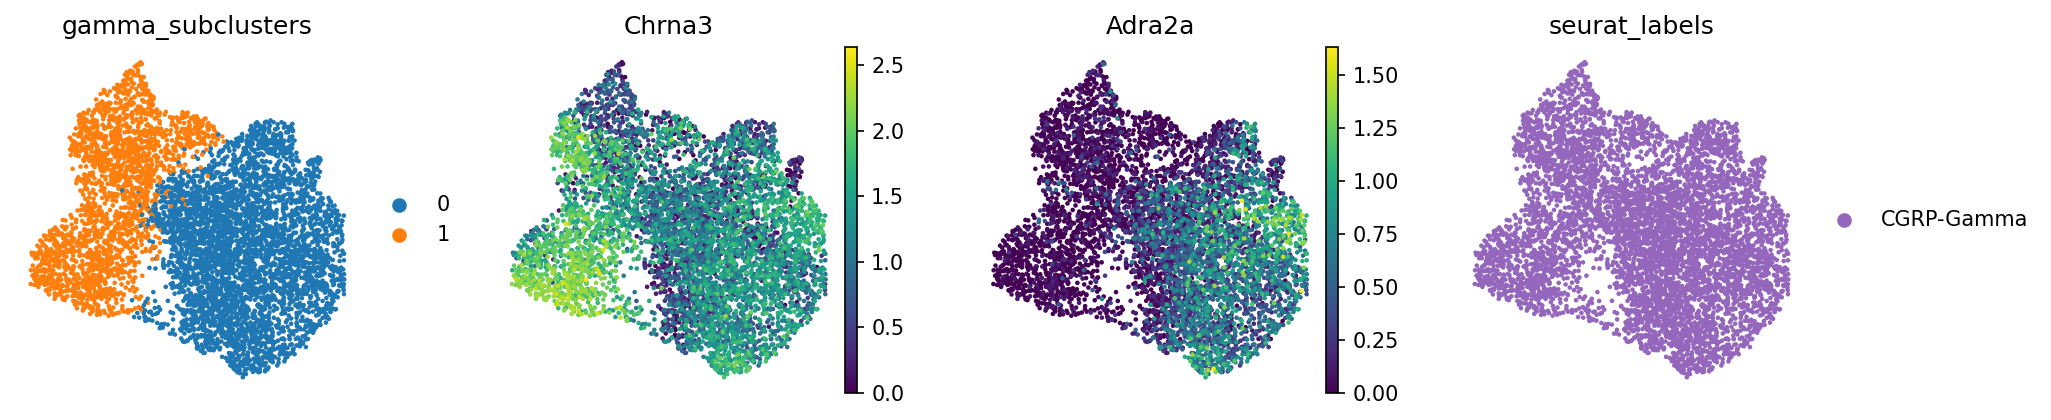

In [17]:
sc.pl.umap(gamma_adata, color=['gamma_subclusters', 'Chrna3', 'Adra2a', 'seurat_labels'], frameon = False)

# Map subclusters onto adata

In [18]:
# 1. Start with the original labels in a new column
adata.obs['neuron_label'] = adata.obs['seurat_labels'].astype(str)

# 2. Map the subset subclusters to your G1/G2 nomenclature
# Based on your UMAP: Cluster 1 = Chrna3 high (G2), Cluster 0 = Adra2a high (G1)
gamma_map = {'1': 'CGRP-Gamma 2', '0': 'CGRP-Gamma 1'}
gamma_adata.obs['refined_label'] = gamma_adata.obs['gamma_subclusters'].map(gamma_map)

# 3. Update the main object's neuron_label column with the refined Gamma labels
# This only overwrites the cells present in gamma_adata
adata.obs.set_index(adata.obs.index, inplace=True) # Ensure indices match
adata.obs.update(gamma_adata.obs[['refined_label']].rename(columns={'refined_label': 'neuron_label'}))

# 4. Finalize as a category for better plotting
adata.obs['neuron_label'] = adata.obs['neuron_label'].astype('category')

In [19]:
assign_cell_type_colors(adata,  key="neuron_label")

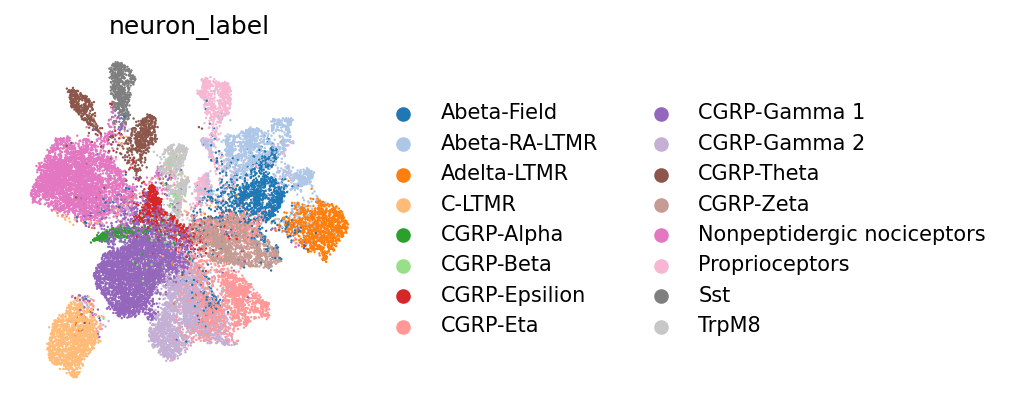

In [20]:
sc.pl.umap(adata, color = 'neuron_label', frameon = False)

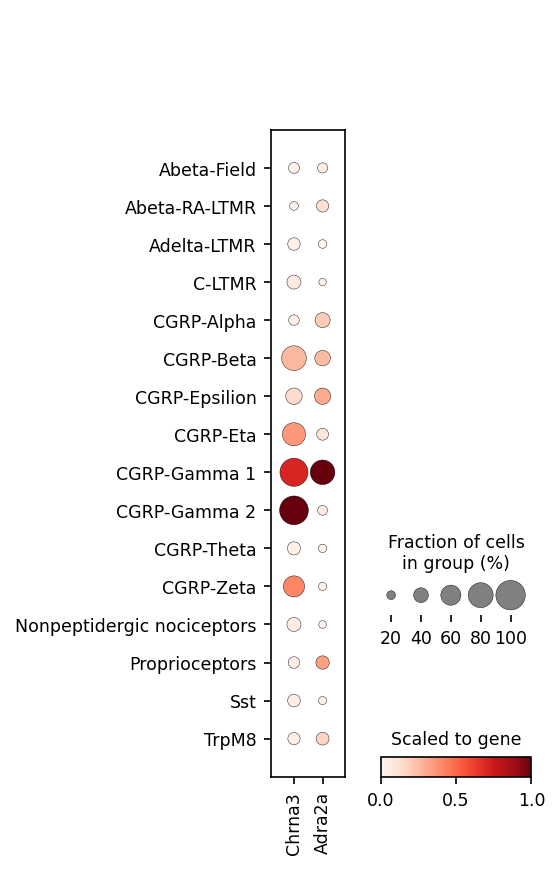

In [21]:
sc.pl.dotplot(adata, ['Chrna3', 'Adra2a'], groupby='neuron_labels', standard_scale='var', colorbar_title = 'Scaled to gene')

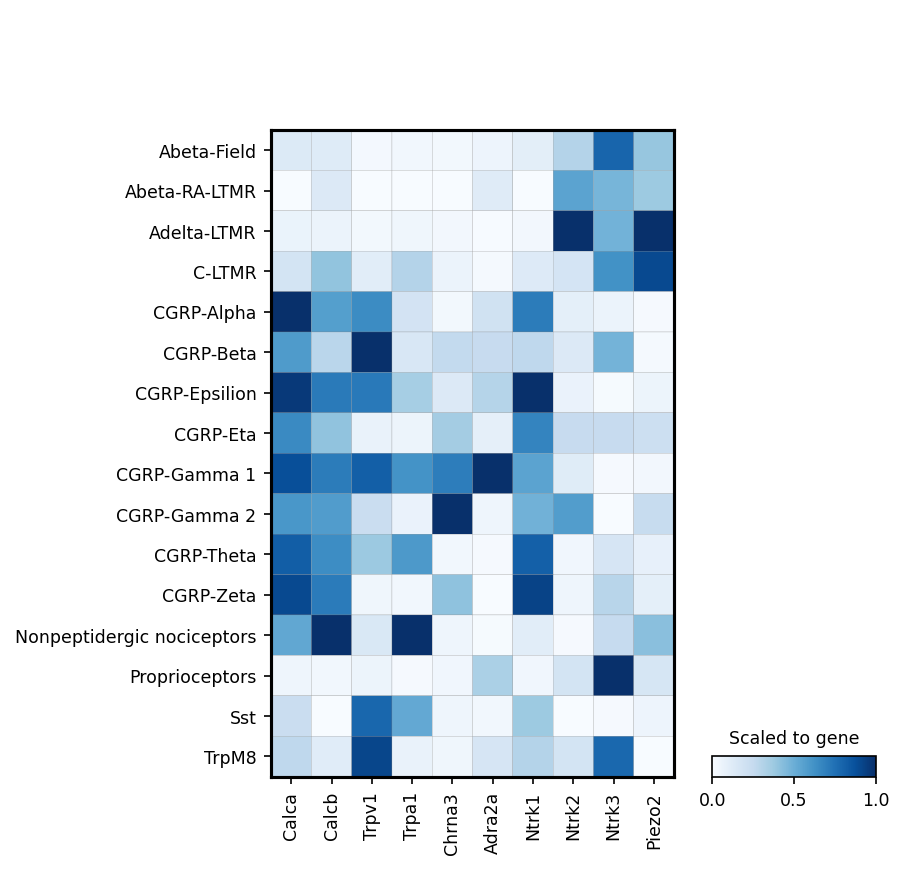

In [46]:
sc.pl.matrixplot(adata, 
                     var_names = ['Calca', 'Calcb', 'Trpv1', 'Trpa1', 'Chrna3', 'Adra2a', 'Ntrk1', 'Ntrk2', 'Ntrk3', 'Piezo2'], 
                     groupby = 'neuron_labels',
                     standard_scale = 'var', 
                     colorbar_title = 'Scaled to gene', 
                     cmap = 'Blues')

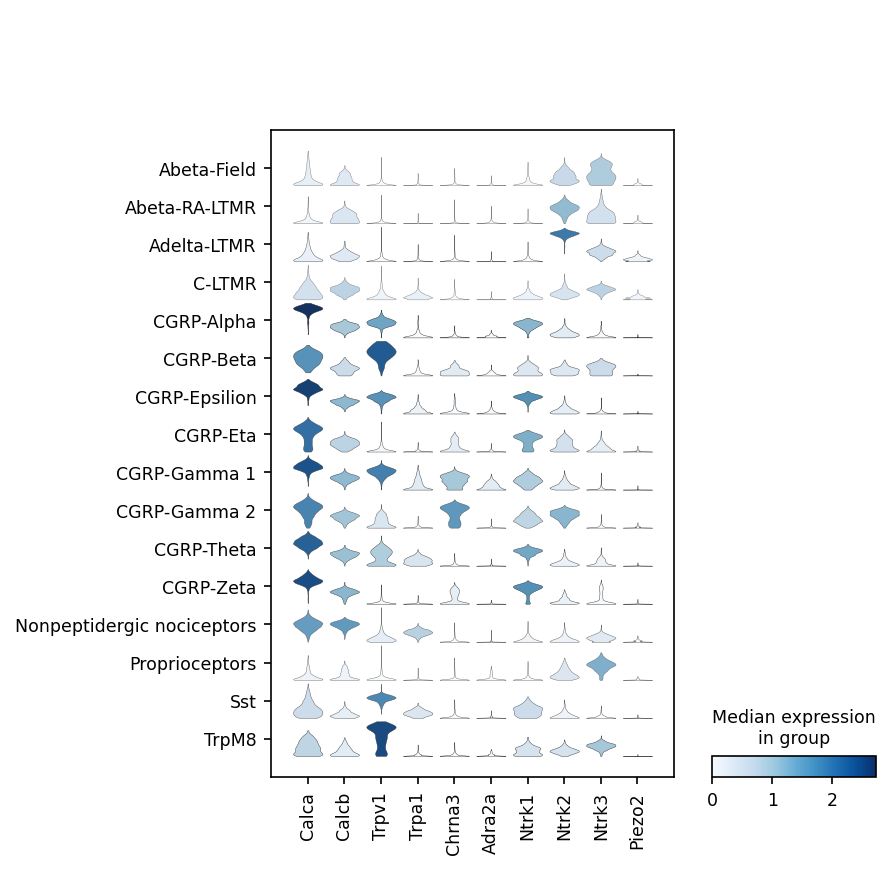

In [47]:
sc.pl.stacked_violin(adata, 
                     var_names = ['Calca', 'Calcb', 'Trpv1', 'Trpa1', 'Chrna3', 'Adra2a', 'Ntrk1', 'Ntrk2', 'Ntrk3', 'Piezo2'], 
                     groupby = 'neuron_labels',
                     cmap = 'Blues')

# Export

In [24]:
adata_path = os.path.join(output_dir, 'neurons-final-labels.h5ad')
adata.write_h5ad(adata_path, compression='gzip')
print(adata_path)

/home/workspace/projects/drg/data/h5ad/export_04/04c_gamma_subtypes/neurons-final-labels.h5ad


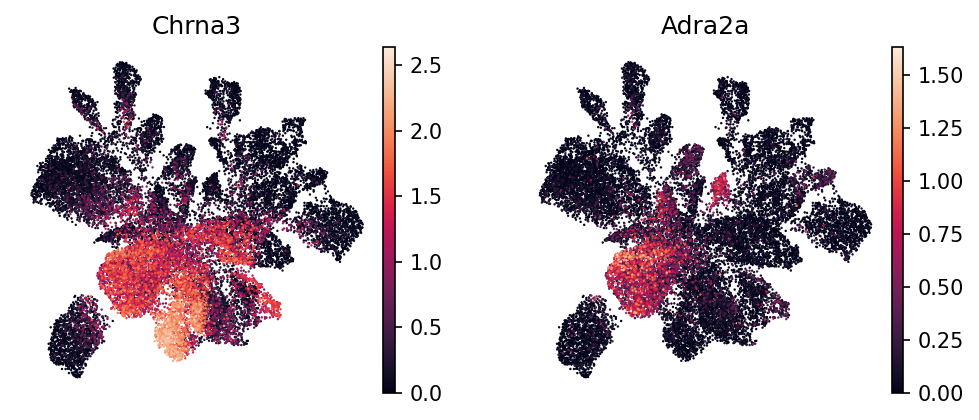

In [27]:
sc.pl.umap(adata, color = ['Chrna3', 'Adra2a'], frameon=False, cmap = 'rocket')